# Market Regime Detection Using Singular Value Decomposition

**A Quantitative Approach to Identifying Market States**

This notebook implements a production-ready framework for detecting market regimes using Singular Value Decomposition (SVD). We analyze real market data to identify distinct market states and transitions between them.

## Overview

Market regimes represent distinct behavioral states where asset correlations, volatility, and return patterns exhibit consistent characteristics. Identifying these regimes is crucial for:

- **Risk Management**: Adjusting position sizes and hedges based on current market state
- **Strategy Selection**: Deploying regime-appropriate trading strategies
- **Portfolio Construction**: Dynamic asset allocation based on detected regime

### Mathematical Foundation

Given a returns matrix $R \in \mathbb{R}^{n \times m}$ where $n$ is the number of days and $m$ is the number of assets, SVD decomposes this matrix as:

$$R = U \Sigma V^T$$

Where:
- $U \in \mathbb{R}^{n \times n}$: Left singular vectors (temporal patterns)
- $\Sigma \in \mathbb{R}^{n \times m}$: Diagonal matrix of singular values
- $V^T \in \mathbb{R}^{m \times m}$: Right singular vectors (asset loadings)

The rows of $V^T$ represent the principal directions in asset space. By projecting daily returns onto these directions, we obtain a low-dimensional representation that captures the dominant market dynamics.

## 1. Environment Setup

In [ ]:
# Install required packages (uncomment if needed)
# !pip install yfinance pandas numpy matplotlib seaborn scipy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)

print("Environment configured successfully.")

Environment configured successfully.


## 2. Data Acquisition

We use S&P 500 sector ETFs to capture broad market dynamics. These ETFs represent the 11 GICS sectors and provide excellent coverage of market-wide regime shifts.

In [2]:
# S&P 500 Sector ETFs
SECTOR_ETFS = {
    'XLK': 'Technology',
    'XLF': 'Financials',
    'XLV': 'Healthcare',
    'XLY': 'Consumer Discretionary',
    'XLP': 'Consumer Staples',
    'XLE': 'Energy',
    'XLI': 'Industrials',
    'XLB': 'Materials',
    'XLU': 'Utilities',
    'XLRE': 'Real Estate',
    'XLC': 'Communication Services'
}

# Date range: Last 3 years of data
END_DATE = datetime.now()
START_DATE = END_DATE - timedelta(days=3*365)

print(f"Fetching data from {START_DATE.date()} to {END_DATE.date()}")
print(f"Sectors: {list(SECTOR_ETFS.values())}")

Fetching data from 2022-12-20 to 2025-12-19
Sectors: ['Technology', 'Financials', 'Healthcare', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Industrials', 'Materials', 'Utilities', 'Real Estate', 'Communication Services']


In [3]:
def fetch_sector_data(tickers: dict, start: datetime, end: datetime) -> pd.DataFrame:
    """Fetch close prices for sector ETFs."""
    symbols = list(tickers.keys())
    
    # Download data (auto_adjust=True is now default, so 'Close' is adjusted)
    data = yf.download(symbols, start=start, end=end, progress=False)
    
    # Handle different yfinance versions
    if 'Close' in data.columns.get_level_values(0) if isinstance(data.columns, pd.MultiIndex) else 'Close' in data.columns:
        data = data['Close']
    elif 'Adj Close' in data.columns.get_level_values(0) if isinstance(data.columns, pd.MultiIndex) else 'Adj Close' in data.columns:
        data = data['Adj Close']
    
    # Handle single ticker case
    if isinstance(data, pd.Series):
        data = data.to_frame(symbols[0])
    
    # Rename columns to sector names
    data.columns = [tickers.get(col, col) for col in data.columns]
    
    return data.dropna()

# Fetch the data
prices = fetch_sector_data(SECTOR_ETFS, START_DATE, END_DATE)
print(f"\nFetched {len(prices)} trading days across {len(prices.columns)} sectors")
prices.tail()

YF.download() has changed argument auto_adjust default to True

Fetched 752 trading days across 11 sectors


,Materials,Communication Services,Energy,Financials,Industrials,Technology,Consumer Staples,Real Estate,Utilities,Healthcare,Consumer Discretionary
Date,,,,,,,,,,,
2025-12-12,45.15,116.55,45.51,54.95,156.74,143.69,79.42,40.75,42.83,154.06,120.70
2025-12-15,45.12,116.57,45.19,54.99,156.99,142.30,79.64,40.91,43.22,156.10,121.73
2025-12-16,45.00,116.65,43.81,54.64,156.06,142.56,79.28,40.55,43.04,154.07,121.93
2025-12-17,45.19,115.81,44.78,54.63,153.53,139.39,79.65,40.73,42.76,153.79,120.52
2025-12-18,45.17,116.47,44.13,54.54,154.53,141.54,79.19,40.48,43.18,153.91,122.34


In [4]:
def compute_returns(prices: pd.DataFrame, method: str = 'log') -> pd.DataFrame:
    """Compute returns from price data.
    
    Args:
        prices: DataFrame of asset prices
        method: 'log' for log returns, 'simple' for arithmetic returns
    """
    if method == 'log':
        return np.log(prices / prices.shift(1)).dropna()
    else:
        return prices.pct_change().dropna()

# Compute log returns
returns = compute_returns(prices, method='log')

print(f"Returns matrix shape: {returns.shape}")
print(f"Date range: {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"\nReturns statistics (annualized):")
print(f"Mean: {(returns.mean() * 252 * 100).round(2).to_dict()}")

Returns matrix shape: (751, 11)
Date range: 2022-12-21 to 2025-12-18

Returns statistics (annualized):
Mean: {'Materials': 6.7, 'Communication Services': 31.34, 'Energy': 4.48, 'Financials': 17.82, 'Industrials': 16.97, 'Technology': 27.94, 'Consumer Staples': 4.62, 'Real Estate': 6.53, 'Utilities': 10.06, 'Healthcare': 6.07, 'Consumer Discretionary': 22.04}


## 3. Exploratory Data Analysis

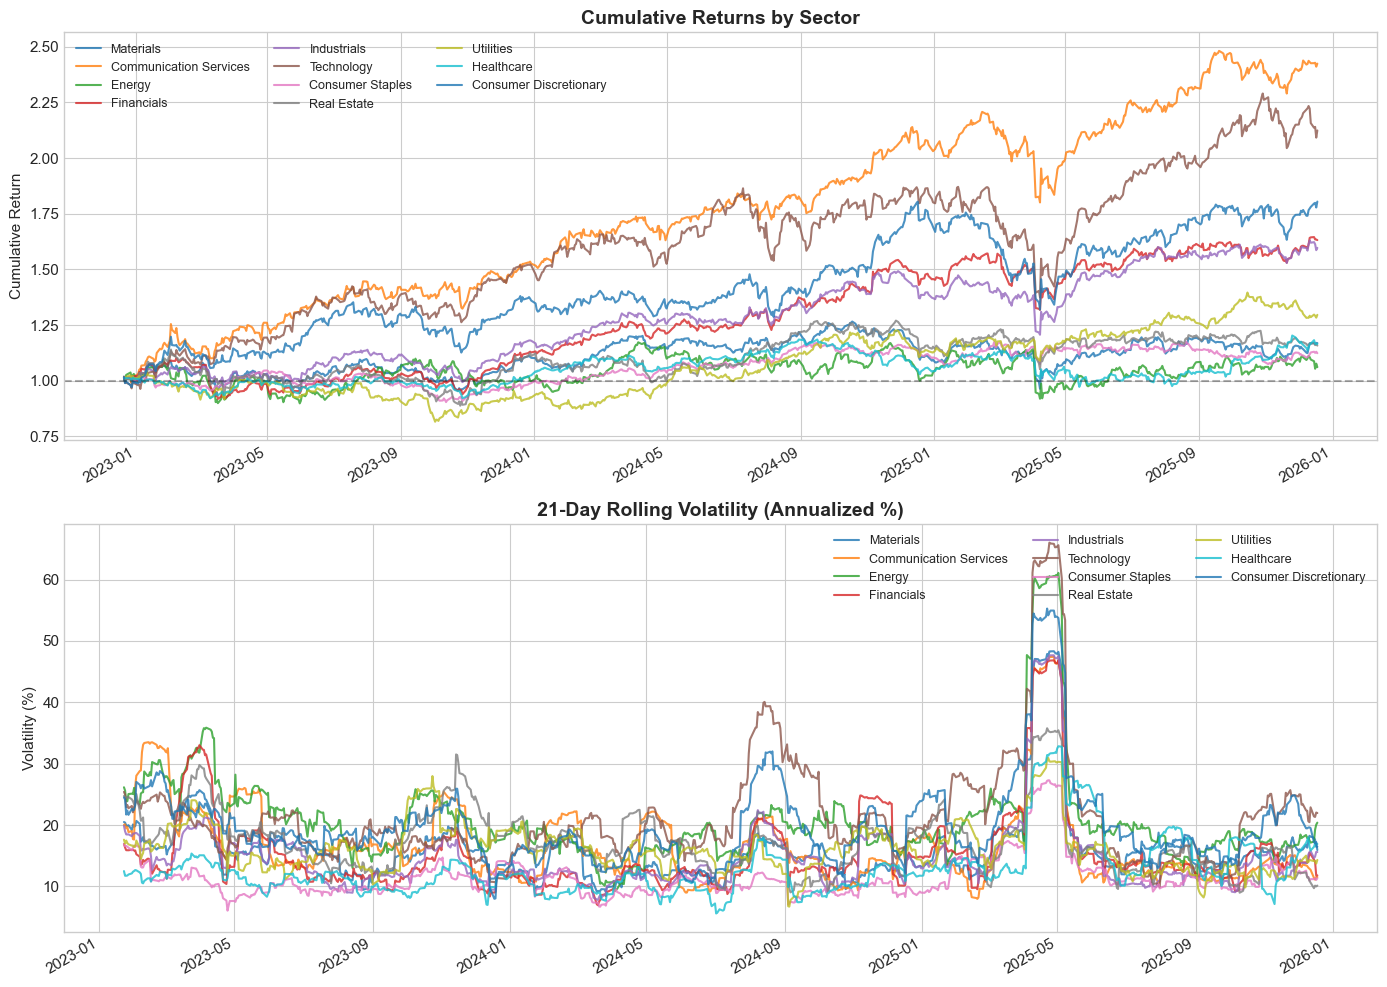

In [5]:
# Cumulative returns visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Cumulative returns
cumulative = (1 + returns).cumprod()
cumulative.plot(ax=axes[0], alpha=0.8)
axes[0].set_title('Cumulative Returns by Sector', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cumulative Return')
axes[0].legend(loc='upper left', ncol=3, fontsize=9)
axes[0].axhline(y=1, color='black', linestyle='--', alpha=0.3)

# Rolling volatility (21-day)
rolling_vol = returns.rolling(21).std() * np.sqrt(252) * 100
rolling_vol.plot(ax=axes[1], alpha=0.8)
axes[1].set_title('21-Day Rolling Volatility (Annualized %)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Volatility (%)')
axes[1].legend(loc='upper right', ncol=3, fontsize=9)

plt.tight_layout()
plt.show()

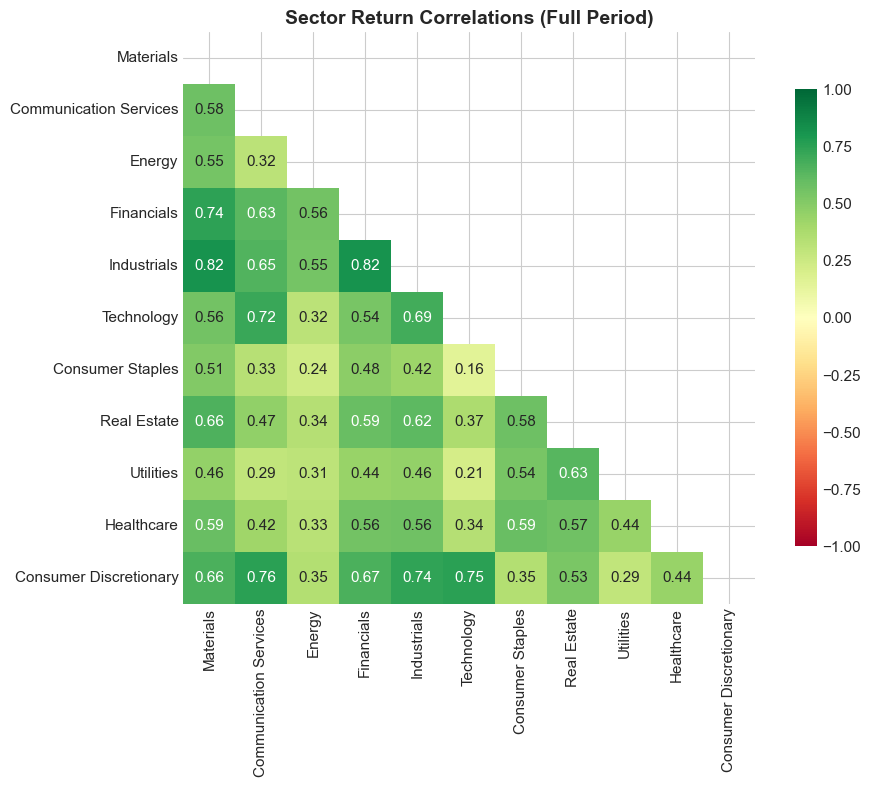

Average pairwise correlation: 0.511


In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
correlation = returns.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))

sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Sector Return Correlations (Full Period)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Average pairwise correlation: {correlation.values[np.triu_indices_from(correlation.values, 1)].mean():.3f}")

## 4. SVD Implementation

We implement the core SVD analysis to extract principal components from the returns matrix.

In [7]:
class MarketRegimeDetector:
    """SVD-based market regime detection framework."""
    
    def __init__(self, n_components: int = 3):
        self.n_components = n_components
        self.U = None
        self.S = None
        self.Vt = None
        self.explained_variance_ratio = None
        self.projections = None
        
    def fit(self, returns: np.ndarray) -> 'MarketRegimeDetector':
        """Perform SVD on the returns matrix."""
        # Center the data (important for PCA interpretation)
        self.mean = returns.mean(axis=0)
        centered = returns - self.mean
        
        # Full SVD decomposition
        self.U, self.S, self.Vt = np.linalg.svd(centered, full_matrices=False)
        
        # Compute explained variance ratios
        variance = self.S ** 2
        self.explained_variance_ratio = variance / variance.sum()
        
        # Project data onto principal components
        self.projections = centered @ self.Vt[:self.n_components].T
        
        return self
    
    def get_loadings(self) -> np.ndarray:
        """Get asset loadings for each principal component."""
        return self.Vt[:self.n_components]
    
    def reconstruct(self, n_components: int = None) -> np.ndarray:
        """Reconstruct returns using specified number of components."""
        k = n_components or self.n_components
        return self.U[:, :k] @ np.diag(self.S[:k]) @ self.Vt[:k] + self.mean
    
    def reconstruction_error(self, n_components: int = None) -> float:
        """Compute reconstruction error (1 - R²)."""
        k = n_components or self.n_components
        return 1 - sum(self.explained_variance_ratio[:k])

# Fit the model
R = returns.values
detector = MarketRegimeDetector(n_components=3)
detector.fit(R)

print("SVD Decomposition Complete")
print(f"Returns matrix shape: {R.shape}")
print(f"U shape: {detector.U.shape}")
print(f"S shape: {detector.S.shape}")
print(f"Vt shape: {detector.Vt.shape}")

SVD Decomposition Complete
Returns matrix shape: (751, 11)
U shape: (751, 11)
S shape: (11,)
Vt shape: (11, 11)


## 5. Variance Analysis

Analyzing how much variance each principal component explains reveals the dimensionality of market dynamics.

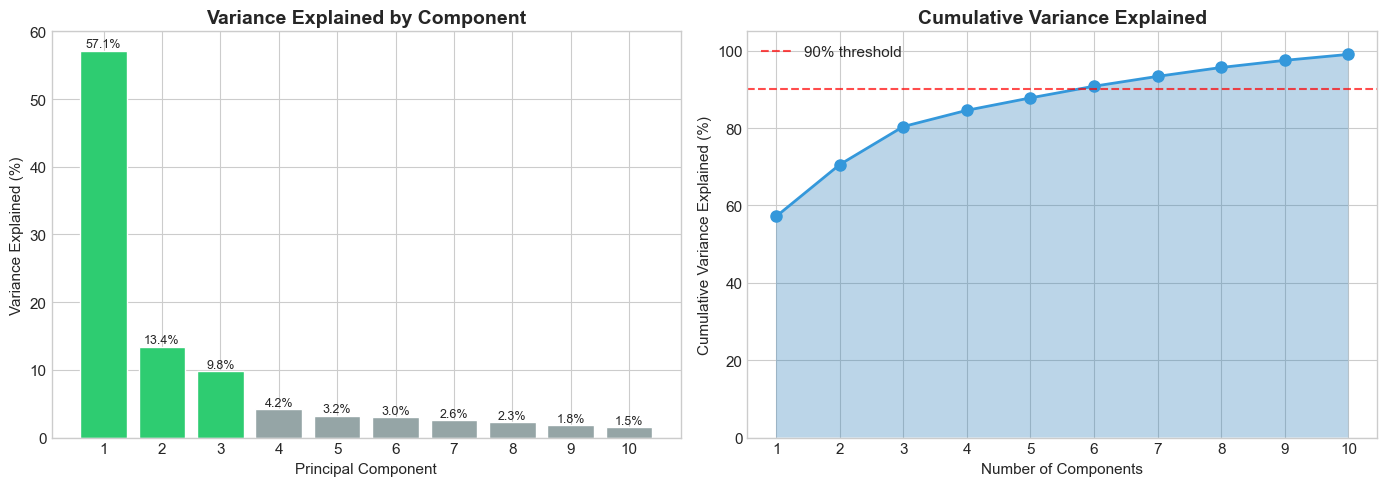


Variance Explained Summary:
--------------------------------------------------
PC1:  57.14% (Cumulative:  57.14%)
PC2:  13.41% (Cumulative:  70.55%)
PC3:   9.84% (Cumulative:  80.38%)
PC4:   4.20% (Cumulative:  84.59%)
PC5:   3.21% (Cumulative:  87.80%)


In [8]:
# Variance explained analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_components = min(10, len(detector.S))
variance_pct = detector.explained_variance_ratio[:n_components] * 100
cumulative_var = np.cumsum(variance_pct)

# Individual variance
colors = ['#2ecc71' if i < 3 else '#95a5a6' for i in range(n_components)]
axes[0].bar(range(1, n_components + 1), variance_pct, color=colors, edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Variance Explained by Component', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, n_components + 1))

# Add value labels
for i, v in enumerate(variance_pct):
    axes[0].text(i + 1, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# Cumulative variance
axes[1].plot(range(1, n_components + 1), cumulative_var, 'o-', color='#3498db', linewidth=2, markersize=8)
axes[1].axhline(y=90, color='red', linestyle='--', alpha=0.7, label='90% threshold')
axes[1].fill_between(range(1, n_components + 1), cumulative_var, alpha=0.3)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, n_components + 1))
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

# Summary table
print("\nVariance Explained Summary:")
print("-" * 50)
for i in range(min(5, n_components)):
    print(f"PC{i+1}: {variance_pct[i]:6.2f}% (Cumulative: {cumulative_var[i]:6.2f}%)")

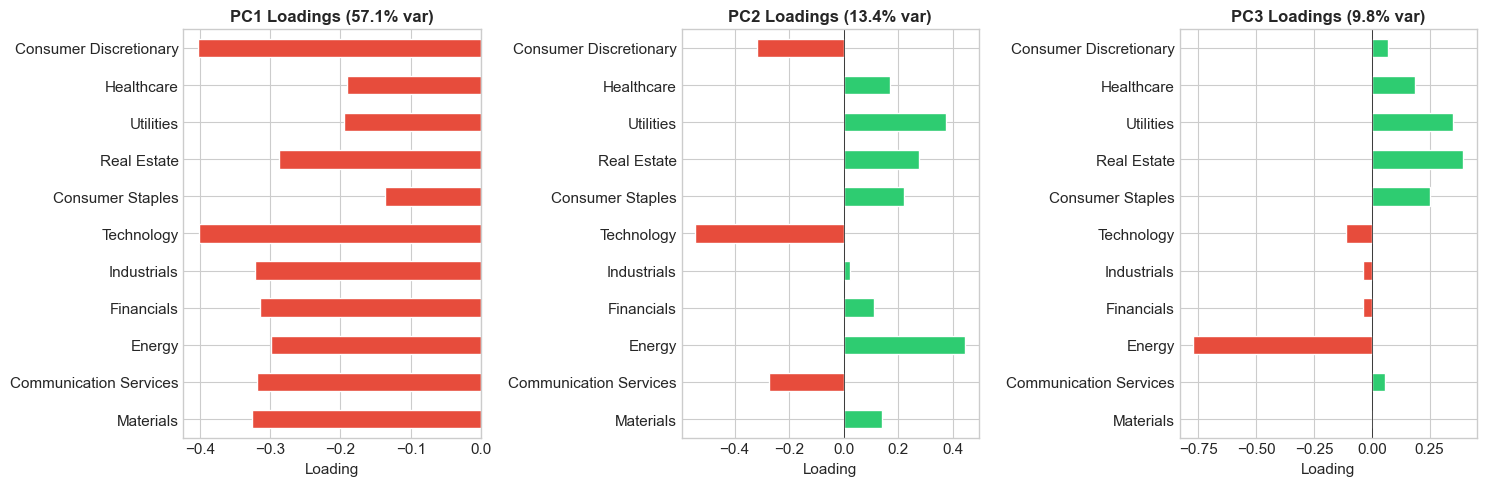


Interpretation:
- PC1: Market factor (all sectors move together)
- PC2: Sector rotation (growth vs. defensive)
- PC3: Specific sector dynamics


In [9]:
# Asset loadings analysis
loadings = detector.get_loadings()
loadings_df = pd.DataFrame(
    loadings.T,
    index=returns.columns,
    columns=[f'PC{i+1}' for i in range(loadings.shape[0])]
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in loadings_df[f'PC{i+1}']]
    loadings_df[f'PC{i+1}'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'PC{i+1} Loadings ({variance_pct[i]:.1f}% var)', fontsize=12, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Loading')
    
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- PC1: Market factor (all sectors move together)")
print("- PC2: Sector rotation (growth vs. defensive)")
print("- PC3: Specific sector dynamics")

## 6. Regime Visualization

Projecting daily returns onto the principal components reveals the underlying market regimes.

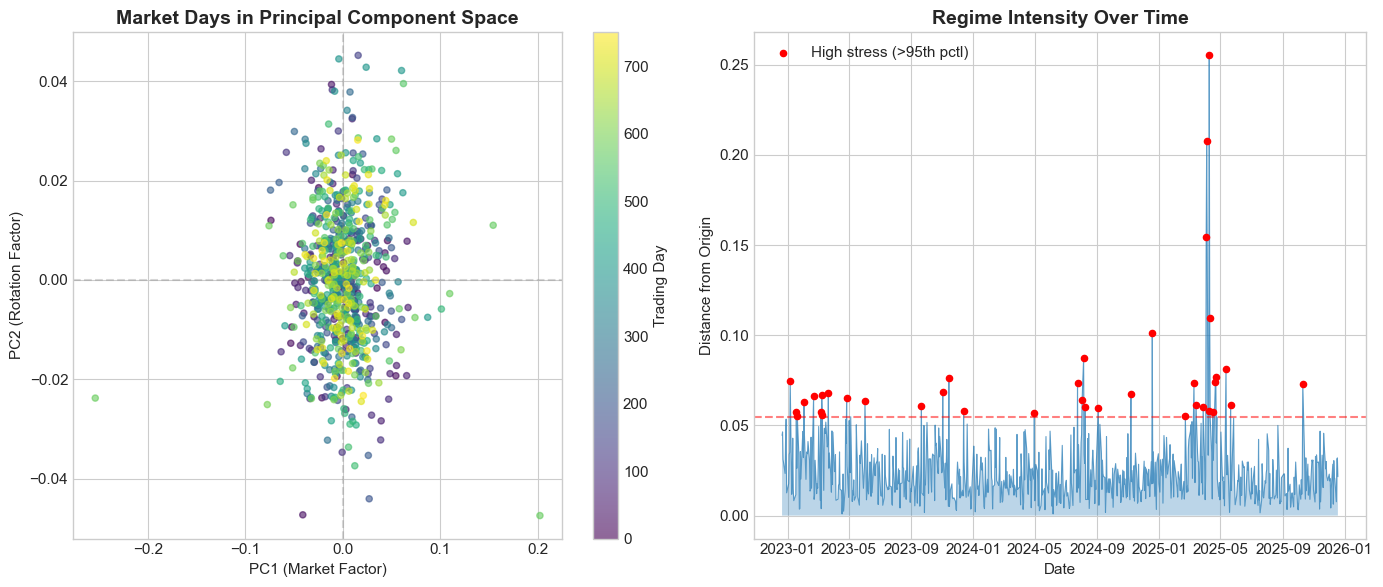

In [10]:
# Create projections DataFrame
projections_df = pd.DataFrame(
    detector.projections,
    index=returns.index,
    columns=[f'PC{i+1}' for i in range(detector.n_components)]
)

# 2D projection plot with time coloring
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Time-colored scatter
time_colors = np.arange(len(projections_df))
scatter = axes[0].scatter(
    projections_df['PC1'], 
    projections_df['PC2'],
    c=time_colors,
    cmap='viridis',
    alpha=0.6,
    s=20
)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
axes[0].set_xlabel('PC1 (Market Factor)')
axes[0].set_ylabel('PC2 (Rotation Factor)')
axes[0].set_title('Market Days in Principal Component Space', fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Trading Day')

# Distance from origin (regime intensity)
distances = np.sqrt(projections_df['PC1']**2 + projections_df['PC2']**2)
axes[1].plot(projections_df.index, distances, alpha=0.7, linewidth=0.8)
axes[1].fill_between(projections_df.index, distances, alpha=0.3)

# Mark high-stress periods
threshold = distances.quantile(0.95)
high_stress = distances[distances > threshold]
axes[1].scatter(high_stress.index, high_stress.values, color='red', s=20, label=f'High stress (>95th pctl)', zorder=5)

axes[1].axhline(y=threshold, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Distance from Origin')
axes[1].set_title('Regime Intensity Over Time', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Regime Classification

We classify market days into distinct regimes based on their position in principal component space.

In [11]:
def classify_regimes(projections: pd.DataFrame, n_regimes: int = 4) -> pd.Series:
    """Classify market days into regimes based on PC1 and PC2 quadrants."""
    pc1_median = projections['PC1'].median()
    pc2_median = projections['PC2'].median()
    
    conditions = [
        (projections['PC1'] >= pc1_median) & (projections['PC2'] >= pc2_median),
        (projections['PC1'] >= pc1_median) & (projections['PC2'] < pc2_median),
        (projections['PC1'] < pc1_median) & (projections['PC2'] >= pc2_median),
        (projections['PC1'] < pc1_median) & (projections['PC2'] < pc2_median),
    ]
    
    regime_names = ['Risk-On Rally', 'Defensive Rally', 'Risk-Off Stress', 'Broad Decline']
    
    regimes = np.select(conditions, regime_names)
    return pd.Series(regimes, index=projections.index, name='regime')

# Classify regimes
regimes = classify_regimes(projections_df)

# Regime statistics
regime_stats = returns.groupby(regimes).agg(['mean', 'std', 'count'])
regime_stats.columns = ['_'.join(col) for col in regime_stats.columns]

print("Regime Distribution:")
print(regimes.value_counts())
print(f"\nTotal days: {len(regimes)}")

Regime Distribution:
regime
Risk-Off Stress    196
Defensive Rally    196
Risk-On Rally      180
Broad Decline      179
Name: count, dtype: int64

Total days: 751


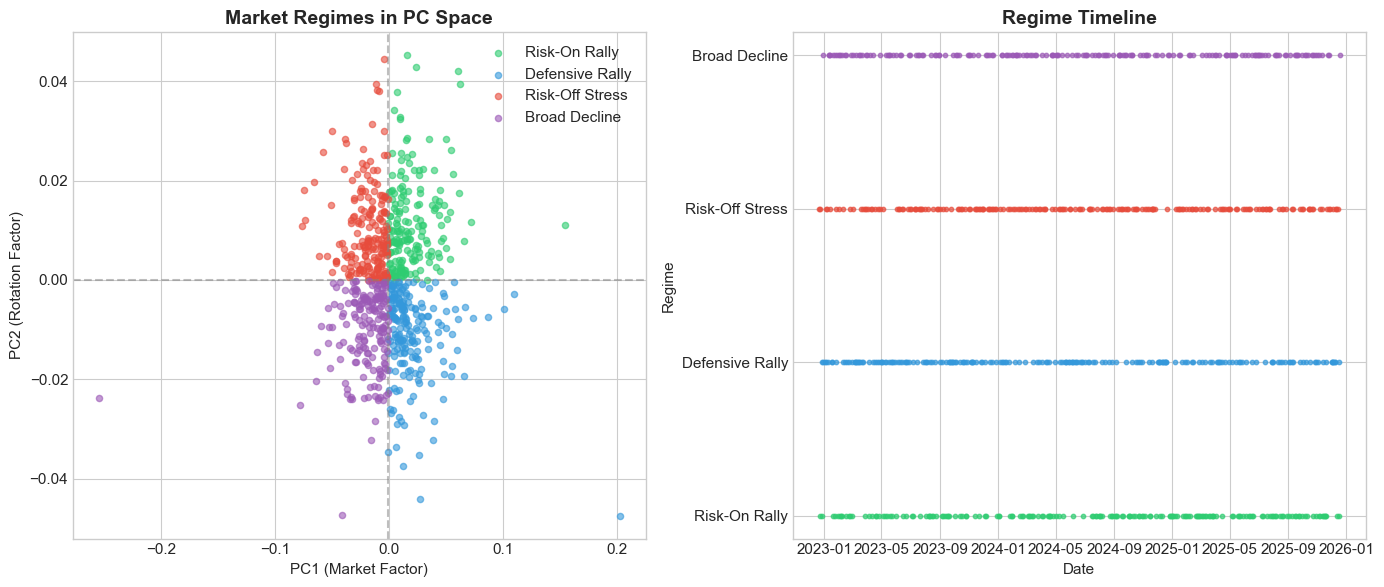

In [12]:
# Regime visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

regime_colors = {
    'Risk-On Rally': '#2ecc71',
    'Defensive Rally': '#3498db',
    'Risk-Off Stress': '#e74c3c',
    'Broad Decline': '#9b59b6'
}

# Scatter plot colored by regime
for regime_name, color in regime_colors.items():
    mask = regimes == regime_name
    axes[0].scatter(
        projections_df.loc[mask, 'PC1'],
        projections_df.loc[mask, 'PC2'],
        c=color,
        label=regime_name,
        alpha=0.6,
        s=20
    )

axes[0].axhline(y=projections_df['PC2'].median(), color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=projections_df['PC1'].median(), color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('PC1 (Market Factor)')
axes[0].set_ylabel('PC2 (Rotation Factor)')
axes[0].set_title('Market Regimes in PC Space', fontsize=14, fontweight='bold')
axes[0].legend()

# Regime timeline
regime_numeric = regimes.map({name: i for i, name in enumerate(regime_colors.keys())})
for i, (regime_name, color) in enumerate(regime_colors.items()):
    mask = regimes == regime_name
    axes[1].scatter(regimes.index[mask], regime_numeric[mask], c=color, s=10, label=regime_name, alpha=0.7)

axes[1].set_xlabel('Date')
axes[1].set_ylabel('Regime')
axes[1].set_yticks(range(4))
axes[1].set_yticklabels(list(regime_colors.keys()))
axes[1].set_title('Regime Timeline', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Regime Characteristics Analysis

In [13]:
# Compute regime statistics
def compute_regime_metrics(returns: pd.DataFrame, regimes: pd.Series) -> pd.DataFrame:
    """Compute comprehensive metrics for each regime."""
    metrics = []
    
    for regime in regimes.unique():
        mask = regimes == regime
        regime_returns = returns[mask]
        
        # Portfolio returns (equal-weighted)
        portfolio_returns = regime_returns.mean(axis=1)
        
        metrics.append({
            'Regime': regime,
            'Days': mask.sum(),
            'Frequency (%)': mask.sum() / len(regimes) * 100,
            'Avg Daily Return (bps)': portfolio_returns.mean() * 10000,
            'Volatility (ann. %)': portfolio_returns.std() * np.sqrt(252) * 100,
            'Sharpe Ratio': portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(252) if portfolio_returns.std() > 0 else 0,
            'Avg Correlation': regime_returns.corr().values[np.triu_indices_from(regime_returns.corr().values, 1)].mean(),
            'Worst Day (%)': portfolio_returns.min() * 100,
            'Best Day (%)': portfolio_returns.max() * 100,
        })
    
    return pd.DataFrame(metrics).set_index('Regime')

regime_metrics = compute_regime_metrics(returns, regimes)
print("\nRegime Characteristics:")
print("=" * 80)
print(regime_metrics.round(2).to_string())


Regime Characteristics:
                 Days  Frequency (%)  Avg Daily Return (bps)  Volatility (ann. %)  Sharpe Ratio  Avg Correlation  Worst Day (%)  Best Day (%)
Regime                                                                                                                                       
Risk-Off Stress   196          26.10                   66.02                 7.10         23.42             0.30           0.01          2.35
Risk-On Rally     180          23.97                  -45.07                 8.54        -13.29             0.29          -4.11          0.16
Defensive Rally   196          26.10                  -58.98                10.76        -13.82             0.47          -6.16          0.07
Broad Decline     179          23.83                   61.02                10.57         14.55             0.44          -0.10          7.32


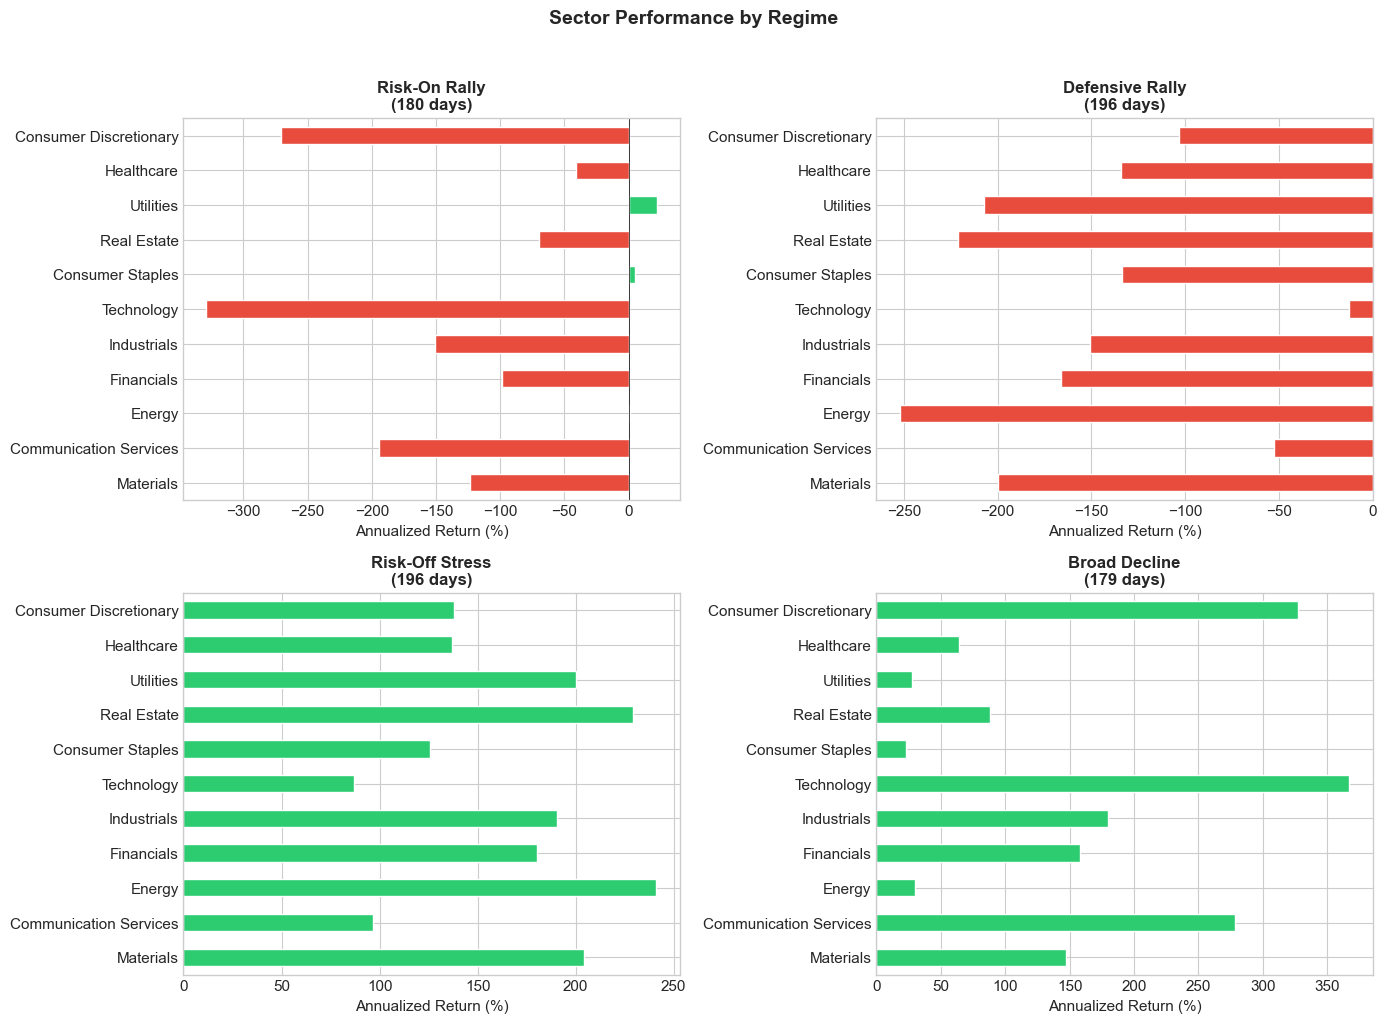

In [14]:
# Sector performance by regime
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, regime in enumerate(regime_colors.keys()):
    mask = regimes == regime
    regime_returns = returns[mask]
    
    # Annualized returns by sector
    ann_returns = regime_returns.mean() * 252 * 100
    colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in ann_returns]
    
    ann_returns.plot(kind='barh', ax=axes[i], color=colors, edgecolor='white')
    axes[i].set_title(f'{regime}\n({mask.sum()} days)', fontsize=12, fontweight='bold')
    axes[i].axvline(x=0, color='black', linewidth=0.5)
    axes[i].set_xlabel('Annualized Return (%)')

plt.suptitle('Sector Performance by Regime', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Regime Transitions Analysis

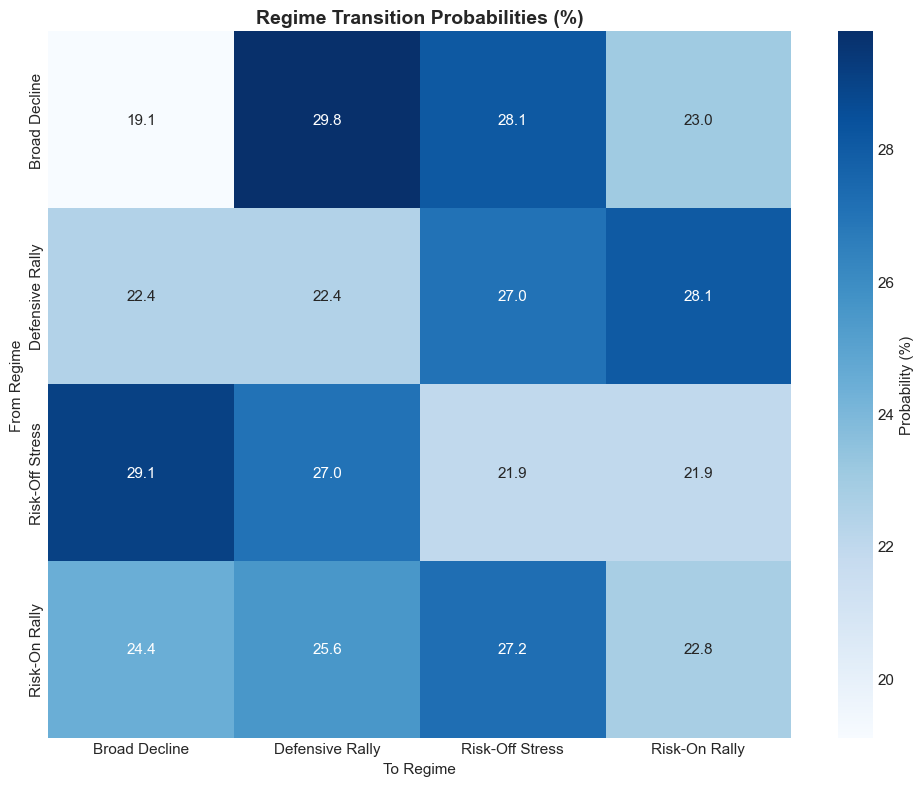


Key Insights:
- Diagonal values show regime persistence (tendency to stay in same regime)
- Off-diagonal values show transition probabilities


In [15]:
def compute_transition_matrix(regimes: pd.Series) -> pd.DataFrame:
    """Compute regime transition probability matrix."""
    transitions = pd.crosstab(
        regimes.shift(1).dropna(),
        regimes.iloc[1:],
        normalize='index'
    ) * 100
    return transitions

transition_matrix = compute_transition_matrix(regimes)

# Visualize transition matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    transition_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    ax=ax,
    cbar_kws={'label': 'Probability (%)'}
)
ax.set_title('Regime Transition Probabilities (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('To Regime')
ax.set_ylabel('From Regime')
plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("- Diagonal values show regime persistence (tendency to stay in same regime)")
print("- Off-diagonal values show transition probabilities")

In [16]:
# Regime duration analysis
def compute_regime_durations(regimes: pd.Series) -> dict:
    """Compute duration statistics for each regime."""
    durations = {regime: [] for regime in regimes.unique()}
    
    current_regime = regimes.iloc[0]
    current_duration = 1
    
    for regime in regimes.iloc[1:]:
        if regime == current_regime:
            current_duration += 1
        else:
            durations[current_regime].append(current_duration)
            current_regime = regime
            current_duration = 1
    
    # Add final duration
    durations[current_regime].append(current_duration)
    
    return durations

durations = compute_regime_durations(regimes)

# Duration statistics
duration_stats = []
for regime, durs in durations.items():
    duration_stats.append({
        'Regime': regime,
        'Occurrences': len(durs),
        'Avg Duration (days)': np.mean(durs),
        'Max Duration (days)': np.max(durs),
        'Min Duration (days)': np.min(durs),
    })

duration_df = pd.DataFrame(duration_stats).set_index('Regime')
print("\nRegime Duration Statistics:")
print("=" * 60)
print(duration_df.round(1).to_string())


Regime Duration Statistics:
                 Occurrences  Avg Duration (days)  Max Duration (days)  Min Duration (days)
Regime                                                                                     
Risk-Off Stress          153                  1.3                    3                    1
Risk-On Rally            139                  1.3                    5                    1
Defensive Rally          152                  1.3                    6                    1
Broad Decline            145                  1.2                    3                    1


## 10. Rolling Regime Analysis

Analyzing how regimes evolve over rolling windows provides insight into market dynamics.

In [17]:
def rolling_svd_analysis(returns: pd.DataFrame, window: int = 63) -> pd.DataFrame:
    """Compute rolling SVD statistics."""
    results = []
    
    for i in range(window, len(returns)):
        window_returns = returns.iloc[i-window:i].values
        
        # SVD on window
        _, S, _ = np.linalg.svd(window_returns - window_returns.mean(axis=0), full_matrices=False)
        variance_ratios = (S ** 2) / (S ** 2).sum()
        
        results.append({
            'date': returns.index[i],
            'pc1_var': variance_ratios[0],
            'pc2_var': variance_ratios[1],
            'pc3_var': variance_ratios[2],
            'top3_var': variance_ratios[:3].sum(),
            'effective_dim': 1 / (variance_ratios ** 2).sum(),  # Participation ratio
        })
    
    return pd.DataFrame(results).set_index('date')

print("Computing rolling SVD analysis (63-day window)...")
rolling_stats = rolling_svd_analysis(returns, window=63)
print("Done!")

Computing rolling SVD analysis (63-day window)...
Done!


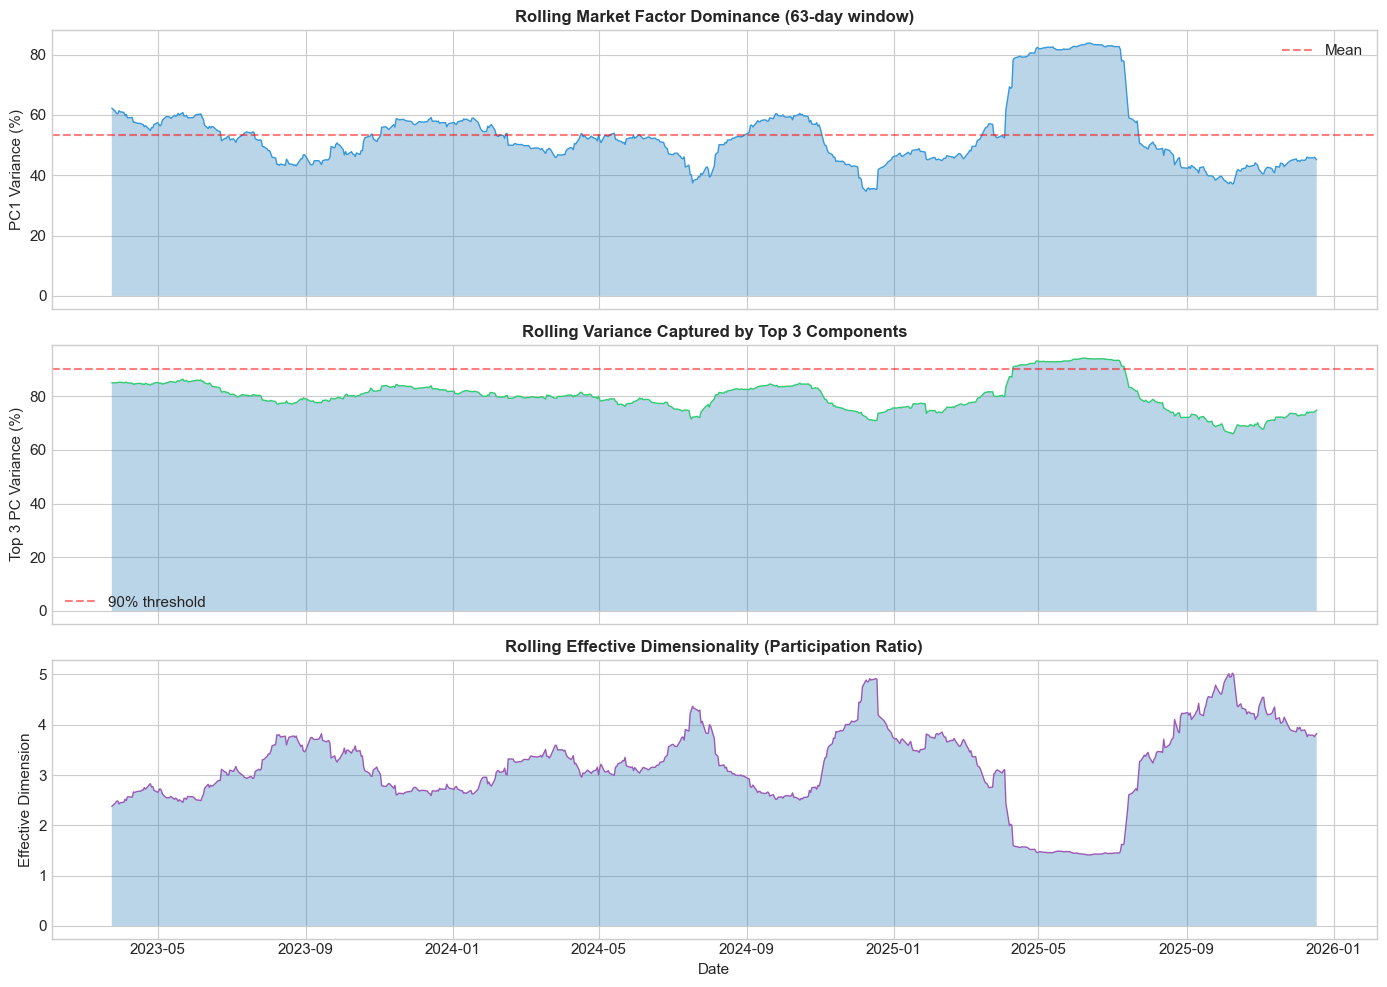


Interpretation:
- High PC1 variance → Strong market factor, sectors moving together
- Low effective dimension → Market dominated by few factors (stress)
- High effective dimension → Diversified returns, sector-specific moves


In [18]:
# Rolling analysis visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# PC1 variance (market integration)
axes[0].plot(rolling_stats.index, rolling_stats['pc1_var'] * 100, color='#3498db', linewidth=1)
axes[0].fill_between(rolling_stats.index, rolling_stats['pc1_var'] * 100, alpha=0.3)
axes[0].axhline(y=rolling_stats['pc1_var'].mean() * 100, color='red', linestyle='--', alpha=0.5, label='Mean')
axes[0].set_ylabel('PC1 Variance (%)')
axes[0].set_title('Rolling Market Factor Dominance (63-day window)', fontsize=12, fontweight='bold')
axes[0].legend()

# Top 3 variance
axes[1].plot(rolling_stats.index, rolling_stats['top3_var'] * 100, color='#2ecc71', linewidth=1)
axes[1].fill_between(rolling_stats.index, rolling_stats['top3_var'] * 100, alpha=0.3)
axes[1].axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90% threshold')
axes[1].set_ylabel('Top 3 PC Variance (%)')
axes[1].set_title('Rolling Variance Captured by Top 3 Components', fontsize=12, fontweight='bold')
axes[1].legend()

# Effective dimensionality
axes[2].plot(rolling_stats.index, rolling_stats['effective_dim'], color='#9b59b6', linewidth=1)
axes[2].fill_between(rolling_stats.index, rolling_stats['effective_dim'], alpha=0.3)
axes[2].set_ylabel('Effective Dimension')
axes[2].set_xlabel('Date')
axes[2].set_title('Rolling Effective Dimensionality (Participation Ratio)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- High PC1 variance → Strong market factor, sectors moving together")
print("- Low effective dimension → Market dominated by few factors (stress)")
print("- High effective dimension → Diversified returns, sector-specific moves")

## 11. Summary & Conclusions

In [19]:
# Final summary
print("="*80)
print("MARKET REGIME ANALYSIS SUMMARY")
print("="*80)
print(f"\nData Period: {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Total Trading Days: {len(returns)}")
print(f"Assets Analyzed: {len(returns.columns)} sector ETFs")
print(f"\nPrincipal Component Analysis:")
print(f"  - PC1 explains {detector.explained_variance_ratio[0]*100:.1f}% of variance (market factor)")
print(f"  - Top 3 PCs explain {sum(detector.explained_variance_ratio[:3])*100:.1f}% of variance")
print(f"\nRegime Statistics:")
for regime in regime_metrics.index:
    print(f"  - {regime}: {regime_metrics.loc[regime, 'Frequency (%)']:.1f}% of days, "
          f"Sharpe: {regime_metrics.loc[regime, 'Sharpe Ratio']:.2f}")
print(f"\nKey Insights:")
print(f"  - Average regime duration: {np.mean([np.mean(d) for d in durations.values()]):.1f} days")
print(f"  - Strongest regime persistence: {transition_matrix.values.diagonal().max():.1f}%")
print("="*80)

MARKET REGIME ANALYSIS SUMMARY

Data Period: 2022-12-21 to 2025-12-18
Total Trading Days: 751
Assets Analyzed: 11 sector ETFs

Principal Component Analysis:
  - PC1 explains 57.1% of variance (market factor)
  - Top 3 PCs explain 80.4% of variance

Regime Statistics:
  - Risk-Off Stress: 26.1% of days, Sharpe: 23.42
  - Risk-On Rally: 24.0% of days, Sharpe: -13.29
  - Defensive Rally: 26.1% of days, Sharpe: -13.82
  - Broad Decline: 23.8% of days, Sharpe: 14.55

Key Insights:
  - Average regime duration: 1.3 days
  - Strongest regime persistence: 22.8%


## 12. Next Steps

This analysis provides a foundation for regime-based trading strategies. Consider:

1. **Strategy Development**
   - Regime-conditional position sizing
   - Dynamic asset allocation based on detected regime
   - Regime-specific alpha signals

2. **Model Enhancements**
   - Hidden Markov Models for probabilistic regime assignment
   - Online/streaming SVD for real-time detection
   - Regime prediction using leading indicators

3. **Risk Management**
   - Regime-aware VaR calculations
   - Dynamic hedging based on regime transitions
   - Stress testing across historical regimes

---

*This notebook was made as part of the QuantFrame educational platform.*